In [275]:
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

In [276]:
# Download latest version
path = kagglehub.dataset_download("saurabhbadole/zomato-delivery-operations-analytics-dataset")

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

print("Dataset downloaded")

Using Colab cache for faster access to the 'zomato-delivery-operations-analytics-dataset' dataset.
Dataset downloaded


In [277]:
df = pd.read_csv(os.path.join(path, csv_file))
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


Handling Missing Value

In [278]:
# Fill numerical columns with median
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

# Fill categorical columns with mode
df['Weather_conditions'] = df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0])
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].mode()[0])
df['Festival'] = df['Festival'].fillna(df['Festival'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df = df.dropna(subset=['Time_Orderd'])

# Check remaining missing values
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64


Modifying the data

In [279]:
import numpy as np

R = 6371.0  # Earth's radius in km

lat1 = np.radians(df['Restaurant_latitude'])
lon1 = np.radians(df['Restaurant_longitude'])
lat2 = np.radians(df['Delivery_location_latitude'])
lon2 = np.radians(df['Delivery_location_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

# Haversine formula
a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

theta = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Distance in km
df['distance'] = R * theta

print(df[['distance']].head())

    distance
0  10.280582
1   6.242319
2  13.787860
3   2.930258
4  19.396618


In [280]:
# Calculate Q1, Q3, and IQR (optional, for reporting)
Q1 = df['distance'].quantile(0.25)
Q3 = df['distance'].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower bound using IQR
lower_bound = Q1 - 1.5 * IQR

# Set a manual upper bound
upper_bound = 25

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Manual Upper Bound: {upper_bound:.2f}")

# Detect outliers
outliers = df[
    (df['distance'] < lower_bound) |
    (df['distance'] > upper_bound)
]

print(f"\nNumber of outliers: {len(outliers)}")
print(outliers[['distance']].head())

Q1: 4.66
Q3: 13.68
IQR: 9.02
Lower Bound: -8.86
Manual Upper Bound: 25.00

Number of outliers: 156
         distance
83    6048.631240
274   6047.919478
1082  3464.082720
1774  5168.516553
1967  5013.585658


In [281]:
df['distance'] = np.where(
    df['distance'] <= 50,
    df['distance'],
    np.nan
)

print(df[['distance', 'distance']].head())

    distance   distance
0  10.280582  10.280582
1   6.242319   6.242319
2  13.787860  13.787860
3   2.930258   2.930258
4  19.396618  19.396618


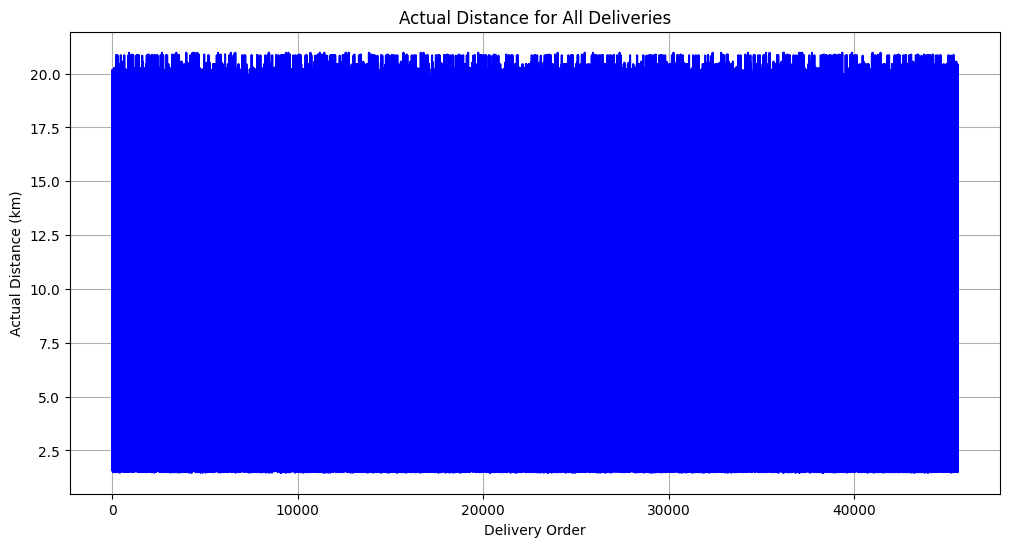

In [282]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['distance'], color='blue', linewidth=1.5)

plt.title('Actual Distance for All Deliveries')
plt.xlabel('Delivery Order')
plt.ylabel('Actual Distance (km)')
plt.grid(True)

plt.show()

In [283]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M', errors='coerce')

df['Preparation_Time'] = (
    df['Time_Order_picked'] - df['Time_Orderd']
).dt.total_seconds() / 60

df.loc[df['Preparation_Time'] < 0, 'Preparation_Time'] += 24 * 60

df['Delivery_Time'] = df['Time_taken (min)'] - df['Preparation_Time']

df['Time_Orderd'] = df['Time_Orderd'].dt.strftime('%H:%M')
df['Time_Order_picked'] = df['Time_Order_picked'].dt.strftime('%H:%M')

# View the results
print(df[['Time_Orderd', 'Time_Order_picked', 'Preparation_Time', 'Delivery_Time']].head())

  Time_Orderd Time_Order_picked  Preparation_Time  Delivery_Time
0       21:55             22:10              15.0           31.0
1       14:55             15:05              10.0           13.0
2       17:30             17:40              10.0           11.0
3       09:20             09:30              10.0           10.0
4       19:50             20:05              15.0           26.0


Renaming the columns name


In [284]:
df.rename(columns={
    "Delivery_person_Age": "Age",
    "Delivery_person_Ratings": "Rating",
    "Road_traffic_density": "Traffic_density"
}, inplace=True)

Dropping irrelvant columns

In [285]:
df = df.drop(columns=["ID", "Delivery_person_ID", "Restaurant_latitude", "Restaurant_longitude", "Delivery_location_latitude","Delivery_location_longitude", "Time_Orderd","Time_Order_picked", "Order_Date"])
df.head()

,Age,Rating,Weather_conditions,Traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance,Preparation_Time,Delivery_Time
0,36.0,4.2,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,15.0,31.0
1,21.0,4.7,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,10.0,13.0
2,23.0,4.7,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,10.0,11.0
3,34.0,4.3,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,10.0,10.0
4,24.0,4.7,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,15.0,26.0


Handling object type columns


In [286]:
print(df['Festival'].unique())
print(df['Festival'].dtype)

['No' 'Yes']
object


In [287]:
df['Festival'] = df['Festival'].map({'Yes': 1, 'No': 0})
print(df['Festival'].unique())

df['Traffic_density'] = df['Traffic_density'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Jam': 3
})

print(df['Traffic_density'].unique())
df.head()

[0 1]
[3 2 1 0]


,Age,Rating,Weather_conditions,Traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance,Preparation_Time,Delivery_Time
0,36.0,4.2,Fog,3,2,Snack,motorcycle,3.0,0,Metropolitian,46,10.280582,15.0,31.0
1,21.0,4.7,Stormy,2,1,Meal,motorcycle,1.0,0,Metropolitian,23,6.242319,10.0,13.0
2,23.0,4.7,Sandstorms,1,1,Drinks,scooter,1.0,0,Metropolitian,21,13.787860,10.0,11.0
3,34.0,4.3,Sandstorms,0,0,Buffet,motorcycle,0.0,0,Metropolitian,20,2.930258,10.0,10.0
4,24.0,4.7,Fog,3,1,Snack,scooter,1.0,0,Metropolitian,41,19.396618,15.0,26.0


In [288]:
# df.sample(50)
print(df['Traffic_density'].unique())
print(df['Type_of_vehicle'].unique())
print(df['Weather_conditions'].unique())
print(df['City'].unique())

[3 2 1 0]
['motorcycle' 'scooter' 'electric_scooter']
['Fog' 'Stormy' 'Sandstorms' 'Windy' 'Cloudy' 'Sunny']
['Metropolitian' 'Urban' 'Semi-Urban']


In [289]:
# df.sample(50)
print(df.isnull().sum())

Age                       0
Rating                    0
Weather_conditions        0
Traffic_density           0
Vehicle_condition         0
Type_of_order             0
Type_of_vehicle           0
multiple_deliveries       0
Festival                  0
City                      0
Time_taken (min)          0
distance                156
Preparation_Time       8446
Delivery_Time          8446
dtype: int64
